<a href="https://colab.research.google.com/github/gosheno/AnimeList/blob/master/testik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ корреляций в психологическом исследовании

Этот ноутбук анализирует корреляции между переменными в психологическом исследовании, разделёнными на блоки.

## 1. Загрузка данных и подготовка

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving test.csv to test (3).csv


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
# ========== 1. ЗАГРУЗКА ДАННЫХ ==========
file_path = "/test.csv"  # Замените на имя вашего файла
df = pd.read_csv(file_path, sep=';', encoding='utf-8')
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[numeric_columns]

print("=" * 80)
print("АНАЛИЗ КОРРЕЛЯЦИЙ В ПСИХОЛОГИЧЕСКОМ ИССЛЕДОВАНИИ")
print("=" * 80)
print(f"Размер данных: {df.shape[0]} строк × {df.shape[1]} столбцов")
%matplotlib inline
# ========== 3. ОПРЕДЕЛЯЕМ БЛОКИ ПЕРЕМЕННЫХ ==========
block1_vars = ['A', 'B', 'C', 'D']
block2_vars = ['уступчивое', 'публичное', 'анонимное', 'экстренное', 'эмоциональное', 'альтруистическое']
block3_vars = [
    'Базовые коммуникативные умения', 'Межличностное понимание', 'Позитивное влияние',
    'Ассертивные умения', 'Самоорганизация', 'Саморегуляция', 'Сотрудничество',
    'Организаторские умения', 'Регуляция конфликтов', 'Комплексные интерсубъектные умения',
    'Коммуникативная компетентность', 'Социальный интеллект', 'Альтероцентрические мения',
    'Толерантность', 'Благожелательность', 'Этические умения', 'Ценностное отношение к людям',
    'Речевые умения', 'Жизнестойкость', 'Психологическое благополучие'
]

# Проверяем наличие переменных
block1_exists = [v for v in block1_vars if v in df_numeric.columns]
block2_exists = [v for v in block2_vars if v in df_numeric.columns]
block3_exists = [v for v in block3_vars if v in df_numeric.columns]

print(f"\nБлок 1 (A-D): {len(block1_exists)} переменных")
print(f"Блок 2 (поведенческие стратегии): {len(block2_exists)} переменных")
print(f"Блок 3 (компетенции и благополучие): {len(block3_exists)} переменных")

# Создаём словарь для определения блока переменной
def get_block(var_name):
    """Определяет, к какому блоку относится переменная"""
    if var_name in block1_exists:
        return "Блок 1 (A-D)"
    elif var_name in block2_exists:
        return "Блок 2 (поведенческие стратегии)"
    elif var_name in block3_exists:
        return "Блок 3 (компетенции и благополучие)"
    else:
        return "Другое"

def get_block_short(var_name):
    """Определяет короткое название блока"""
    if var_name in block1_exists:
        return "Б1"
    elif var_name in block2_exists:
        return "Б2"
    elif var_name in block3_exists:
        return "Б3"
    else:
        return "Др"
# ========== 2. ВЫДЕЛЯЕМ ЧИСЛОВЫЕ ДАННЫЕ ==========
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[numeric_columns]
# ========== 4. РАСЧЁТ ПОЛНОЙ КОРРЕЛЯЦИОННОЙ МАТРИЦЫ ==========
corr_matrix = df_numeric.corr(method='pearson')
# ========== 5. ВЫЯВЛЕНИЕ ВСЕХ КОРРЕЛЯЦИЙ ==========


# Находим все корреляции (исключая диагональ)
all_correlations = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]

        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        block1 = get_block(var1)
        block2 = get_block(var2)

        # Определяем тип связи (внутриблоковая или межблоковая)
        if block1 == block2:
            relation_type = "Внутриблоковая"
        else:
            relation_type = "Межблоковая"

        # Определяем силу связи
        if abs(r) >= 0.7:
            strength = "Очень сильная"
        elif abs(r) >= 0.5:
            strength = "Сильная"
        elif abs(r) >= 0.3:
            strength = "Умеренная"
        else:
            strength = "Слабая"

        all_correlations.append({
            'Переменная 1': var1,
            'Блок 1': block1,
            'Переменная 2': var2,
            'Блок 2': block2,
            'r (Пирсона)': round(r, 3),
            'Сила связи': strength,
            'Направление': 'Положительная' if r > 0 else 'Отрицательная',
            'Тип связи': relation_type
        })


АНАЛИЗ КОРРЕЛЯЦИЙ В ПСИХОЛОГИЧЕСКОМ ИССЛЕДОВАНИИ
Размер данных: 40 строк × 31 столбцов

Блок 1 (A-D): 4 переменных
Блок 2 (поведенческие стратегии): 6 переменных
Блок 3 (компетенции и благополучие): 20 переменных


✅ Корреляционная матрица сохранена

Линия 1 (между D и уступчивое): D на позиции 3, уступчивое на позиции 4
   Линия будет на позиции: 4
Линия 2 (между альтруистическое и Базовые коммуникативные умения):
   альтруистическое на позиции 9
   Базовые коммуникативные умения на позиции 10
   Линия будет на позиции: 10


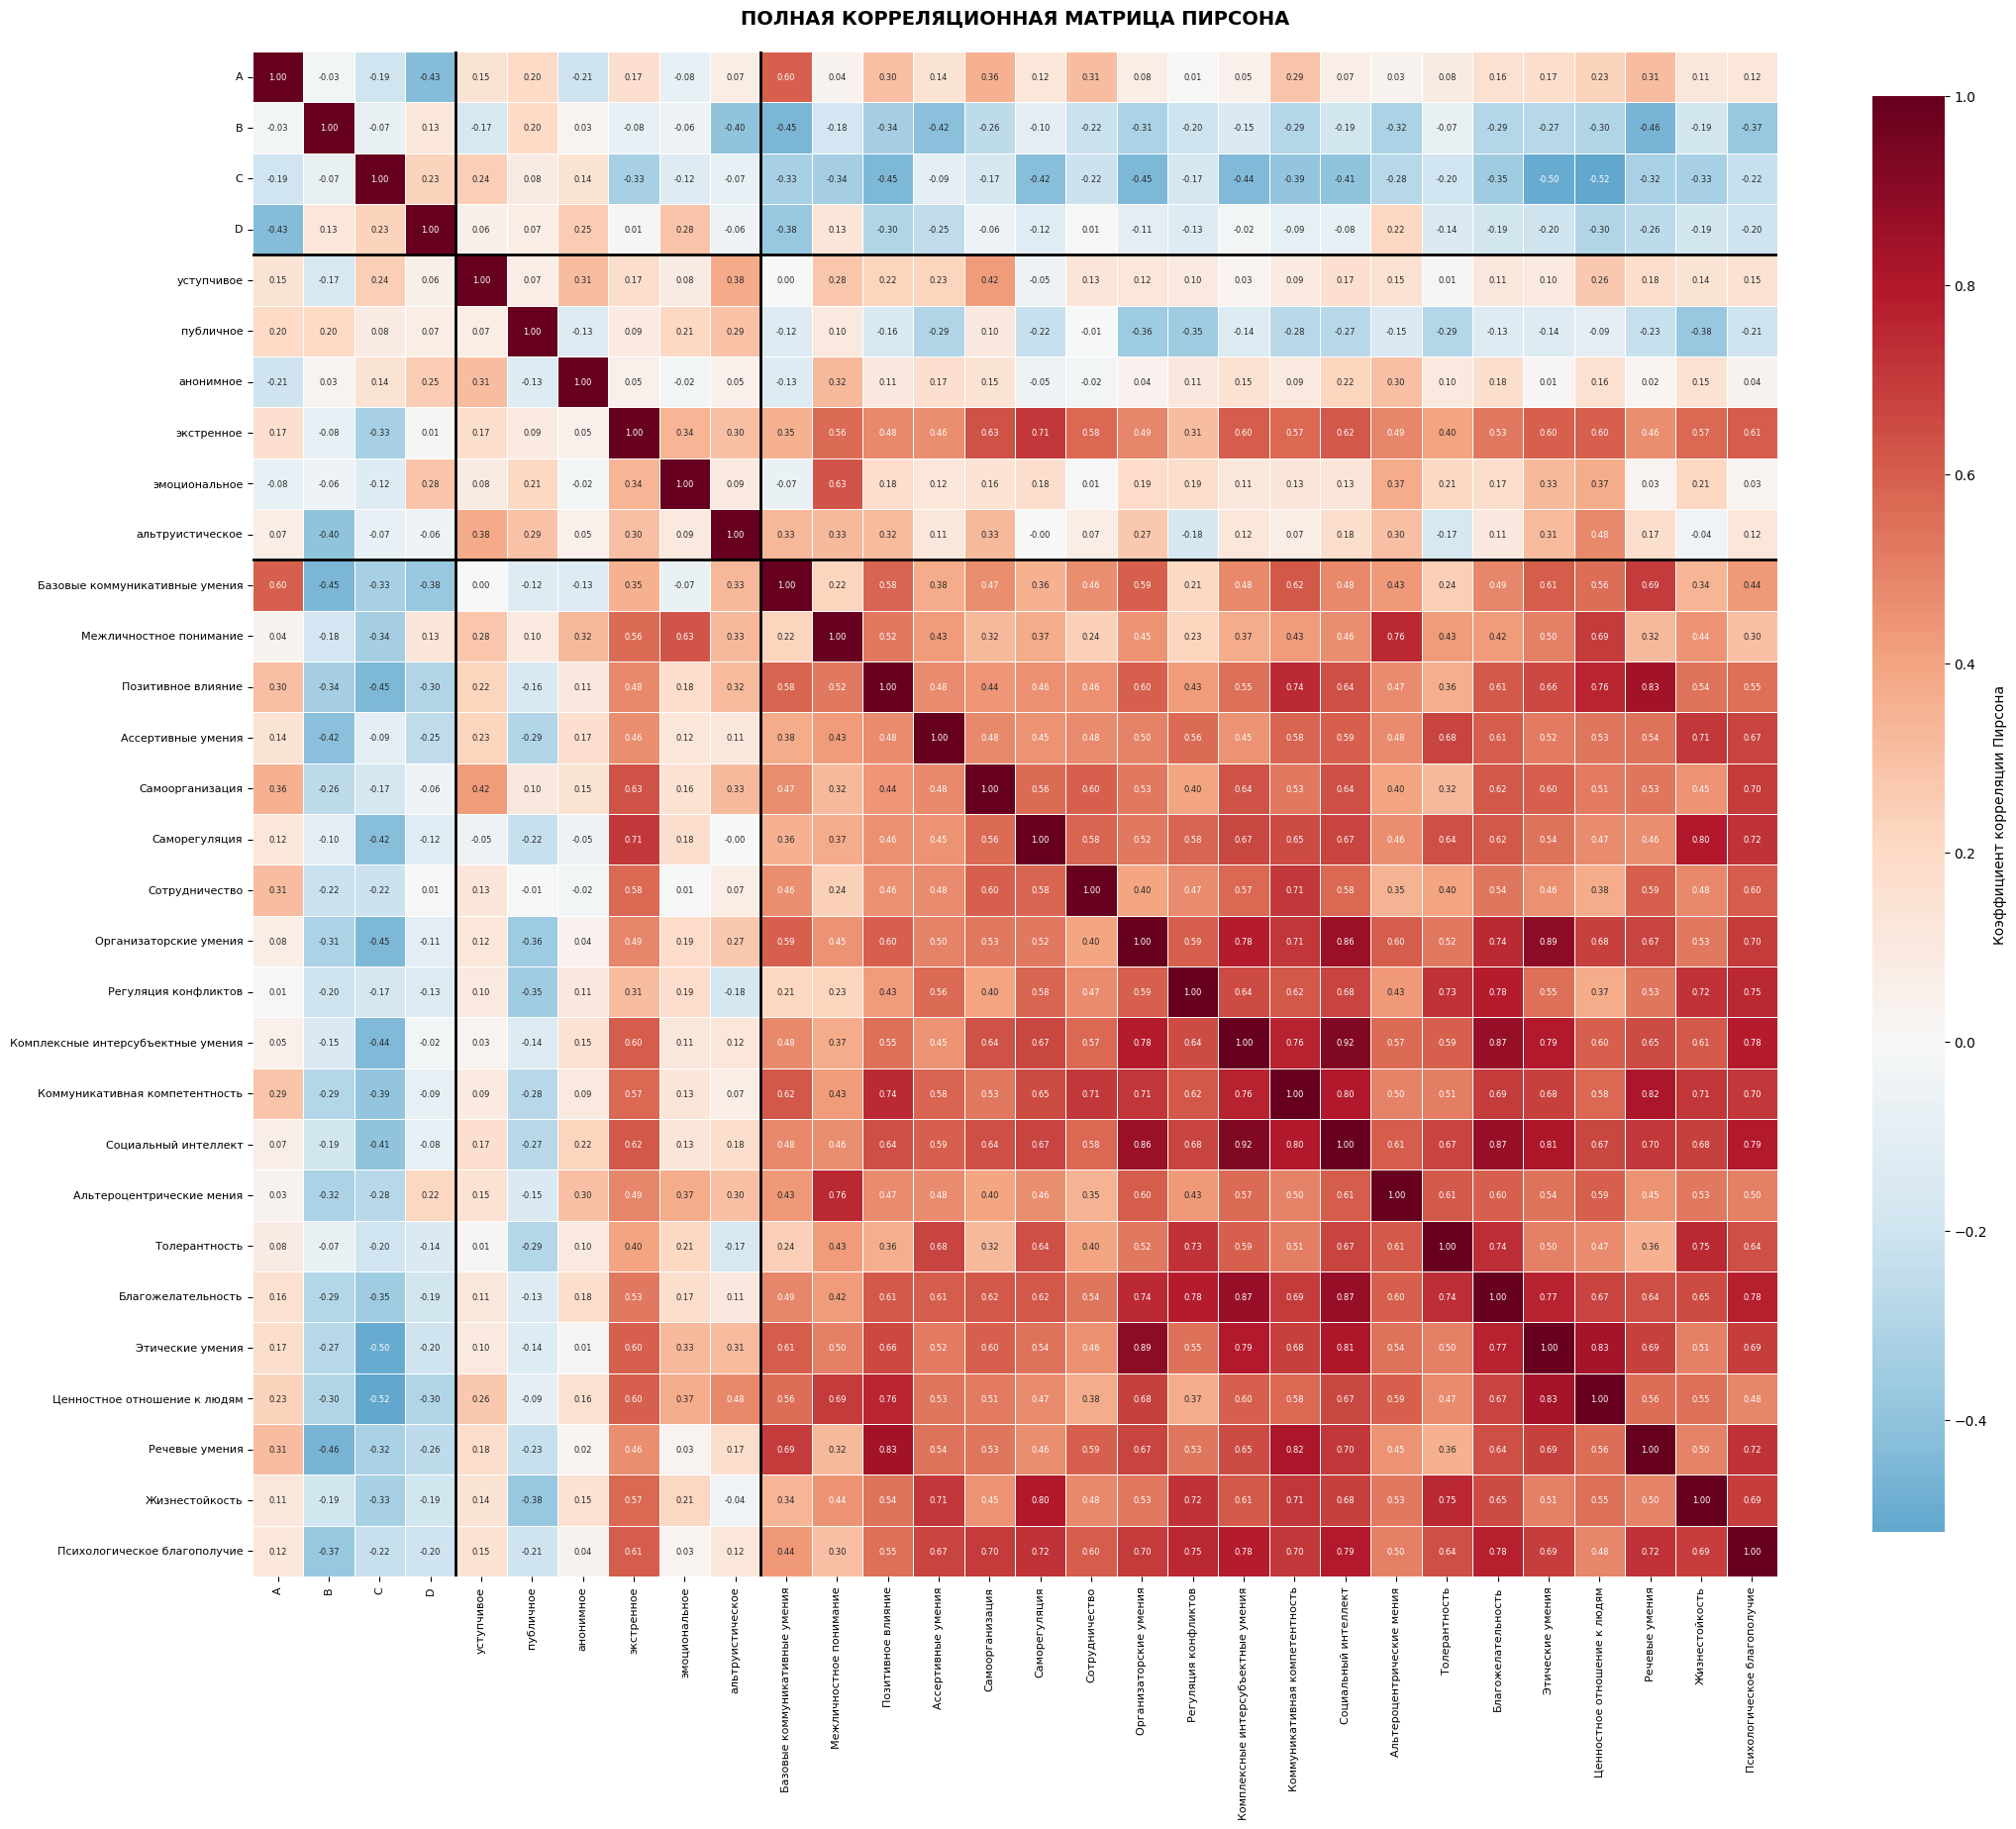

In [ ]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[numeric_columns]

# ========== 3. КОРРЕЛЯЦИОННАЯ МАТРИЦА ==========
corr_matrix = df_numeric.corr(method='pearson')

# Сохраняем полную матрицу
corr_matrix.to_csv("correlation_matrix_full.csv", encoding='utf-8-sig')
print(f"✅ Корреляционная матрица сохранена")

# ========== 4. ОПРЕДЕЛЕНИЕ ПОЗИЦИЙ ДЛЯ ЛИНИЙ ==========
# Получаем список всех переменных в правильном порядке
variables = corr_matrix.columns.tolist()

# Находим индексы для линий
# Линия 1: между "D" и "уступчивое"
try:
    idx_D = variables.index('D')
    idx_уступчивое = variables.index('уступчивое')
    line1_pos = (idx_уступчивое)  # Среднее значение для линии между ними
    print(f"\nЛиния 1 (между D и уступчивое): D на позиции {idx_D}, уступчивое на позиции {idx_уступчивое}")
    print(f"   Линия будет на позиции: {line1_pos}")
except ValueError as e:
    print(f"\n⚠️ Не найдена переменная: {e}")
    line1_pos = None

# Линия 2: между "альтруистическое" и "Базовые коммуникативные умения"
try:
    idx_альтруистическое = variables.index('альтруистическое')
    idx_базовые = variables.index('Базовые коммуникативные умения')
    line2_pos = (idx_базовые)
    print(f"Линия 2 (между альтруистическое и Базовые коммуникативные умения):")
    print(f"   альтруистическое на позиции {idx_альтруистическое}")
    print(f"   Базовые коммуникативные умения на позиции {idx_базовые}")
    print(f"   Линия будет на позиции: {line2_pos}")
except ValueError as e:
    print(f"\n⚠️ Не найдена переменная: {e}")
    line2_pos = None


# ========== 5. ВИЗУАЛИЗАЦИЯ С ЛИНИЯМИ ==========

# 5.1 ПОЛНАЯ ТЕПЛОВАЯ КАРТА С ЛИНИЯМИ (с цифрами)
fig, ax = plt.subplots(figsize=(22, 20))

# Рисуем тепловую карту
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 6},
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции Пирсона"},
            ax=ax)

# Добавляем вертикальные и горизонтальные линии
# Линия 1 (между D и уступчивое)
if line1_pos is not None:
    # Вертикальная линия
    ax.axvline(x=line1_pos, color='black', linewidth=2, linestyle='-')
    # Горизонтальная линия
    ax.axhline(y=line1_pos, color='black', linewidth=2, linestyle='-')

# Линия 2 (между альтруистическое и Базовые коммуникативные умения)
if line2_pos is not None:
    # Вертикальная линия
    ax.axvline(x=line2_pos, color='black', linewidth=2, linestyle='-')
    # Горизонтальная линия
    ax.axhline(y=line2_pos, color='black', linewidth=2, linestyle='-')

# Настройка заголовка и подписей
plt.title('ПОЛНАЯ КОРРЕЛЯЦИОННАЯ МАТРИЦА ПИРСОНА',
          fontsize=14, pad=20, fontweight='bold')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

# Добавляем легенду для линий
from matplotlib.lines import Line2D

plt.tight_layout()
plt.savefig('correlation_matrix_with_lines.png', dpi=300, bbox_inches='tight')
plt.show()


## 2. Анализ сильных корреляций

In [ ]:
# ========== 6. ВЫЯВЛЕНИЕ СИЛЬНЫХ МЕЖБЛОКОВЫХ КОРРЕЛЯЦИЙ ==========
print("\n" + "=" * 80)
print("СИЛЬНЫЕ МЕЖБЛОКОВЫЕ КОРРЕЛЯЦИИ (|r| ≥ 0.5)")
print("=" * 80)

# Фильтруем только сильные межблоковые корреляции
strong_between = [c for c in all_correlations if abs(c['r (Пирсона)']) >= 0.5 and c['Тип связи'] == 'Межблоковая']
strong_between.sort(key=lambda x: abs(x['r (Пирсона)']), reverse=True)

if strong_between:
    print(f"\nНайдено {len(strong_between)} сильных межблоковых корреляций (|r| ≥ 0.5):\n")

    # Выводим с информацией о блоках
    for i, corr in enumerate(strong_between, 1):
        print(f"{i:2d}. {corr['Переменная 1']} [{corr['Блок 1']}] ↔ {corr['Переменная 2']} [{corr['Блок 2']}]")
        print(f"     r = {corr['r (Пирсона)']:.3f} ({corr['Сила связи']}, {corr['Направление']})\n")

    # Сохраняем
    strong_between_df = pd.DataFrame(strong_between)
    strong_between_df.to_csv("strong_between_block_correlations.csv", index=False, encoding='utf-8-sig')
    print("\n✅ Сохранено: strong_between_block_correlations.csv")

    # Статистика по парам блоков
    print("\n" + "-" * 80)
    print("СТАТИСТИКА ПО МЕЖБЛОКОВЫМ СВЯЗЯМ:")
    print("-" * 80)

    block_pairs = [
        ('Блок 1 (A-D)', 'Блок 2 (поведенческие стратегии)'),
        ('Блок 1 (A-D)', 'Блок 3 (компетенции и благополучие)'),
        ('Блок 2 (поведенческие стратегии)', 'Блок 3 (компетенции и благополучие)')
    ]

    for block_a, block_b in block_pairs:
        between = [c for c in strong_between if
                  ((c['Блок 1'] == block_a) and (c['Блок 2'] == block_b)) or
                  ((c['Блок 1'] == block_b) and (c['Блок 2'] == block_a))]

        if between:
            print(f"\n{block_a} ↔ {block_b}:")
            for corr in between:
                print(f"  • {corr['Переменная 1']} ↔ {corr['Переменная 2']}: r = {corr['r (Пирсона)']:.3f}")

else:
    print("\n⚠️ Сильных межблоковых корреляций (|r| ≥ 0.5) не обнаружено")


СИЛЬНЫЕ МЕЖБЛОКОВЫЕ КОРРЕЛЯЦИИ (|r| ≥ 0.5)

Найдено 15 сильных межблоковых корреляций (|r| ≥ 0.5):

 1. экстренное [Блок 2 (поведенческие стратегии)] ↔ Саморегуляция [Блок 3 (компетенции и благополучие)]
     r = 0.707 (Очень сильная, Положительная)

 2. экстренное [Блок 2 (поведенческие стратегии)] ↔ Самоорганизация [Блок 3 (компетенции и благополучие)]
     r = 0.635 (Сильная, Положительная)

 3. эмоциональное [Блок 2 (поведенческие стратегии)] ↔ Межличностное понимание [Блок 3 (компетенции и благополучие)]
     r = 0.628 (Сильная, Положительная)

 4. экстренное [Блок 2 (поведенческие стратегии)] ↔ Социальный интеллект [Блок 3 (компетенции и благополучие)]
     r = 0.619 (Сильная, Положительная)

 5. экстренное [Блок 2 (поведенческие стратегии)] ↔ Психологическое благополучие [Блок 3 (компетенции и благополучие)]
     r = 0.606 (Сильная, Положительная)

 6. экстренное [Блок 2 (поведенческие стратегии)] ↔ Комплексные интерсубъектные умения [Блок 3 (компетенции и благополучие)]
     r

In [ ]:

# ========== 3. ОПРЕДЕЛЯЕМ ТРИ БЛОКА ПЕРЕМЕННЫХ ==========

# БЛОК 1: от "A" до "D"
block1_vars = ['A', 'B', 'C', 'D']
# Проверяем, какие переменные из блока есть в данных
block1_exists = [var for var in block1_vars if var in df_numeric.columns]
print(f"\nБлок 1 (A-D): {block1_exists}")

# БЛОК 2: от "уступчивое" до "альтруистическое"
block2_vars = ['уступчивое', 'публичное', 'анонимное', 'экстренное', 'эмоциональное', 'альтруистическое']
block2_exists = [var for var in block2_vars if var in df_numeric.columns]
print(f"Блок 2 (уступчивое - альтруистическое): {block2_exists}")

# БЛОК 3: от "Базовые коммуникативные умения" до "Психологическое благополучие"
block3_vars = [
    'Базовые коммуникативные умения',
    'Межличностное понимание',
    'Позитивное влияние',
    'Ассертивные умения',
    'Самоорганизация',
    'Саморегуляция',
    'Сотрудничество',
    'Организаторские умения',
    'Регуляция конфликтов',
    'Комплексные интерсубъектные умения',
    'Коммуникативная компетентность',
    'Социальный интеллект',
    'Альтероцентрические мения',
    'Толерантность',
    'Благожелательность',
    'Этические умения',
    'Ценностное отношение к людям',
    'Речевые умения',
    'Жизнестойкость',
    'Психологическое благополучие'
]
block3_exists = [var for var in block3_vars if var in df_numeric.columns]
print(f"Блок 3 (Базовые умения - Психологическое благополучие): {len(block3_exists)} переменных")


Блок 1 (A-D): ['A', 'B', 'C', 'D']
Блок 2 (уступчивое - альтруистическое): ['уступчивое', 'публичное', 'анонимное', 'экстренное', 'эмоциональное', 'альтруистическое']
Блок 3 (Базовые умения - Психологическое благополучие): 20 переменных


## 3. Корреляции внутри блоков


МАТРИЦА 1: КОРРЕЛЯЦИИ МЕЖДУ A, B, C, D
       A      B      C      D
A  1.000 -0.027 -0.194 -0.431
B -0.027  1.000 -0.073  0.127
C -0.194 -0.073  1.000  0.234
D -0.431  0.127  0.234  1.000


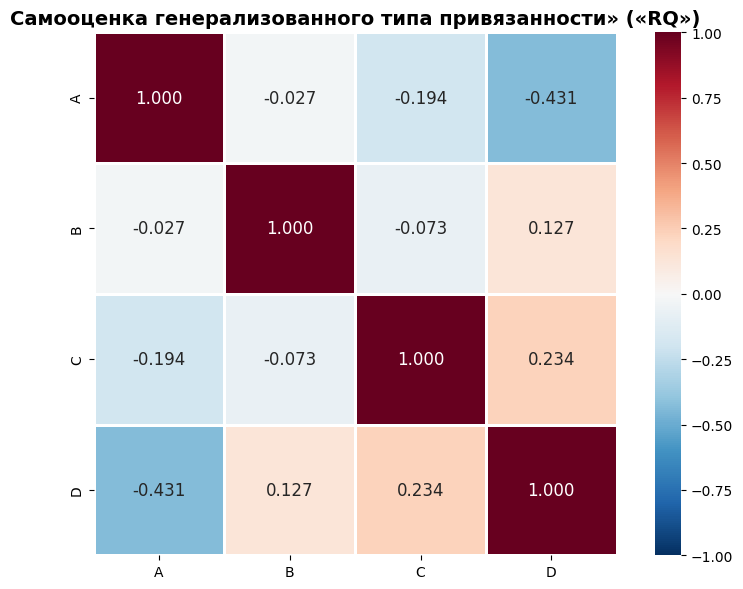

In [ ]:
# ========== 4.1 КОРРЕЛЯЦИИ БЛОКА 1: A, B, C, D ==========
if len(block1_exists) >= 2:
    df_block1 = df_numeric[block1_exists]
    corr_block1 = df_block1.corr(method='pearson')

    print("\n" + "=" * 60)
    print("МАТРИЦА 1: КОРРЕЛЯЦИИ МЕЖДУ A, B, C, D")
    print("=" * 60)
    print(corr_block1.round(3))

    # Сохраняем
    corr_block1.to_csv("correlation_matrix_block1_A_D.csv", encoding='utf-8-sig')


    # Визуализация
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_block1,
                annot=True,
                fmt='.3f',
                cmap='RdBu_r',
                center=0,
                square=True,
                linewidths=1,
                annot_kws={'size': 12},
                vmin=-1, vmax=1)
    plt.title('Самооценка генерализованного типа привязанности» («RQ»)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_matrix_block1_A_D.png', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("\n⚠️ Блок 1 содержит менее 2 переменных, пропускаем...")


МАТРИЦА 3: КОРРЕЛЯЦИИ (Базовые умения → Психологическое благополучие)
                                    Базовые коммуникативные умения  \
Базовые коммуникативные умения                               1.000   
Межличностное понимание                                      0.224   
Позитивное влияние                                           0.584   
Ассертивные умения                                           0.376   
Самоорганизация                                              0.465   
Саморегуляция                                                0.355   
Сотрудничество                                               0.463   
Организаторские умения                                       0.594   
Регуляция конфликтов                                         0.209   
Комплексные интерсубъектные умения                           0.478   
Коммуникативная компетентность                               0.622   
Социальный интеллект                                         0.482   
Альтероцентрические

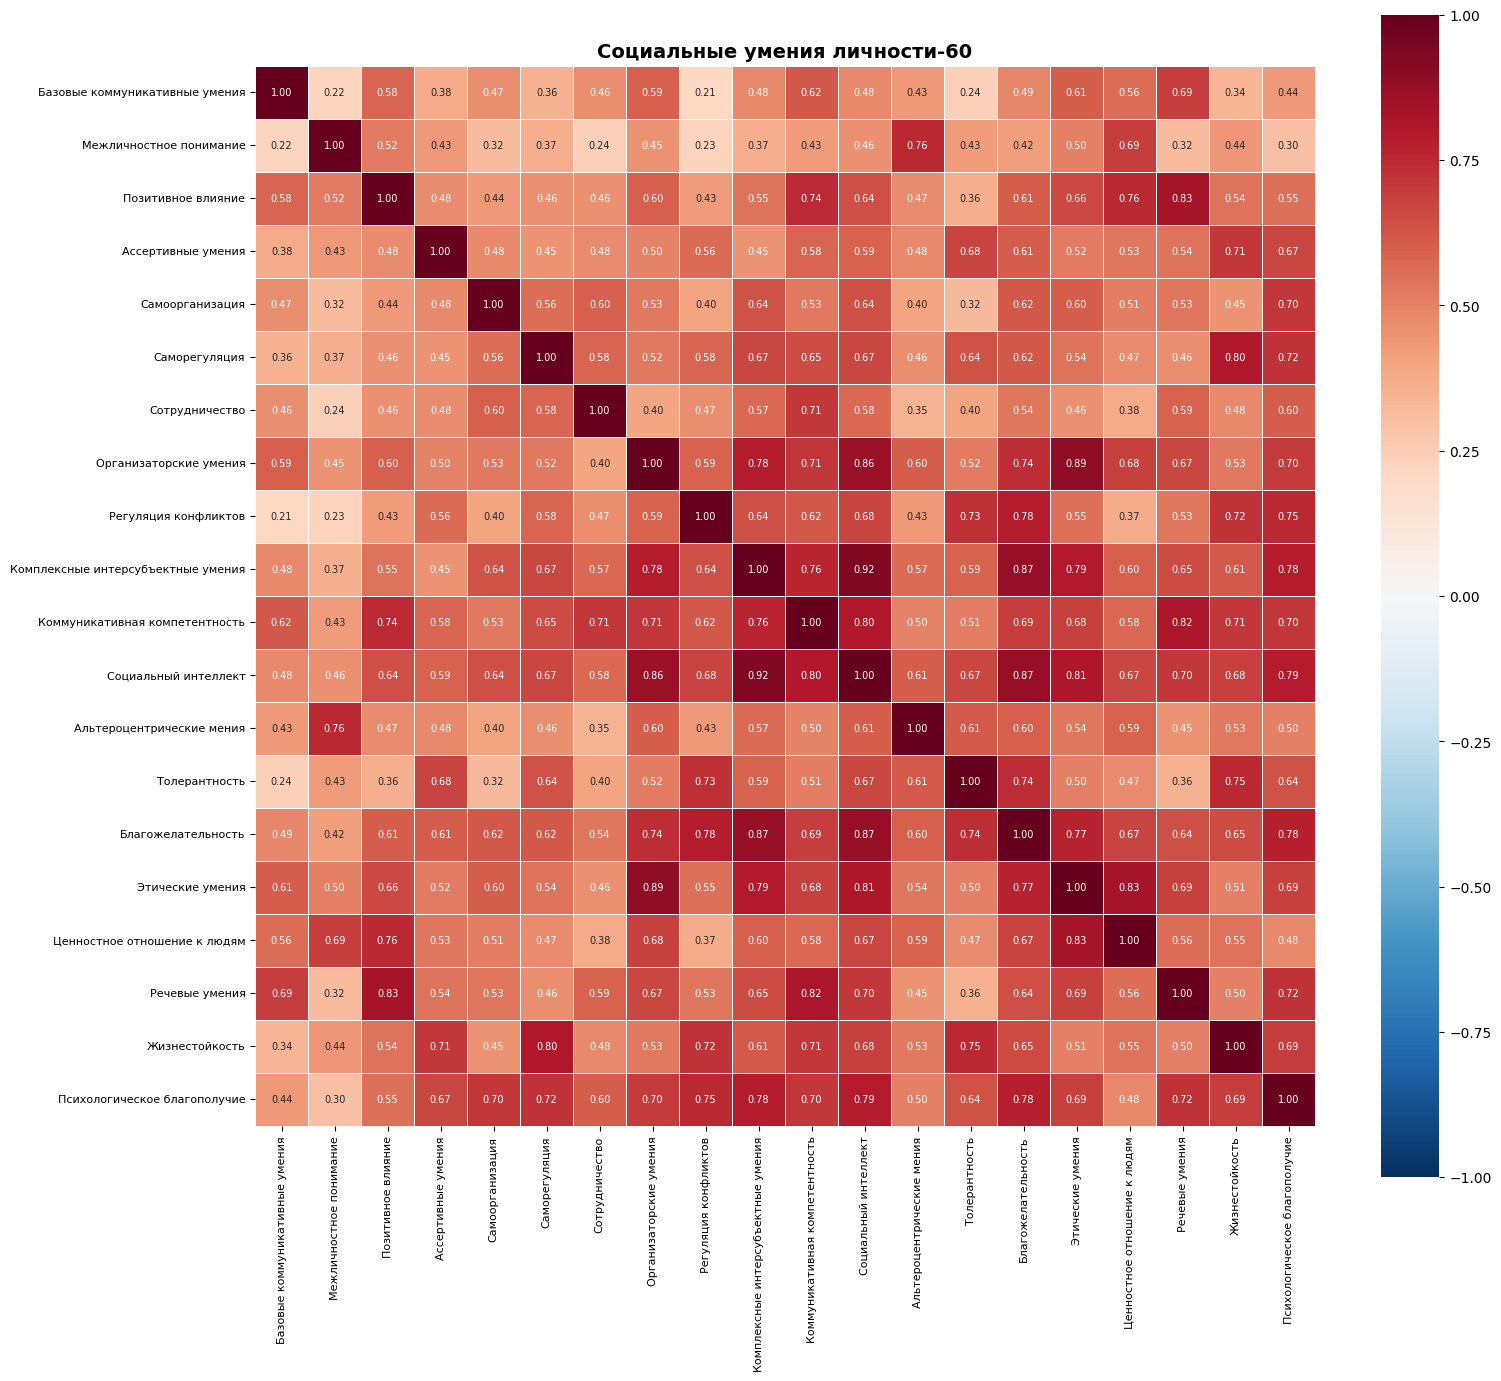

In [ ]:
# ========== 4.3 КОРРЕЛЯЦИИ БЛОКА 3: Базовые умения - Психологическое благополучие ==========
if len(block3_exists) >= 2:
    df_block3 = df_numeric[block3_exists]
    corr_block3 = df_block3.corr(method='pearson')

    print("\n" + "=" * 60)
    print("МАТРИЦА 3: КОРРЕЛЯЦИИ (Базовые умения → Психологическое благополучие)")
    print("=" * 60)
    print(corr_block3.round(3))

    # Сохраняем
    corr_block3.to_csv("correlation_matrix_block3_competencies.csv", encoding='utf-8-sig')


    # Визуализация (большой размер из-за 20 переменных)
    plt.figure(figsize=(16, 14))
    sns.heatmap(corr_block3,
                annot=True,
                fmt='.2f',
                cmap='RdBu_r',
                center=0,
                square=True,
                linewidths=0.5,
                annot_kws={'size': 7},
                vmin=-1, vmax=1)
    plt.title('Социальные умения личности-60',
              fontsize=14, fontweight='bold')
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig('correlation_matrix_block3_competencies.png', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("\n⚠️ Блок 3 содержит менее 2 переменных, пропускаем...")

## 4. Корреляции между блоками


КОРРЕЛЯЦИИ МЕЖДУ БЛОКАМИ

Корреляции между A-D и поведенческими стратегиями:
   уступчивое  публичное  анонимное  экстренное  эмоциональное  \
A       0.146      0.200     -0.208       0.168         -0.081   
B      -0.168      0.204      0.031      -0.076         -0.059   
C       0.245      0.084      0.141      -0.335         -0.121   
D       0.057      0.070      0.253       0.015          0.282   

   альтруистическое  
A             0.069  
B            -0.402  
C            -0.074  
D            -0.062  


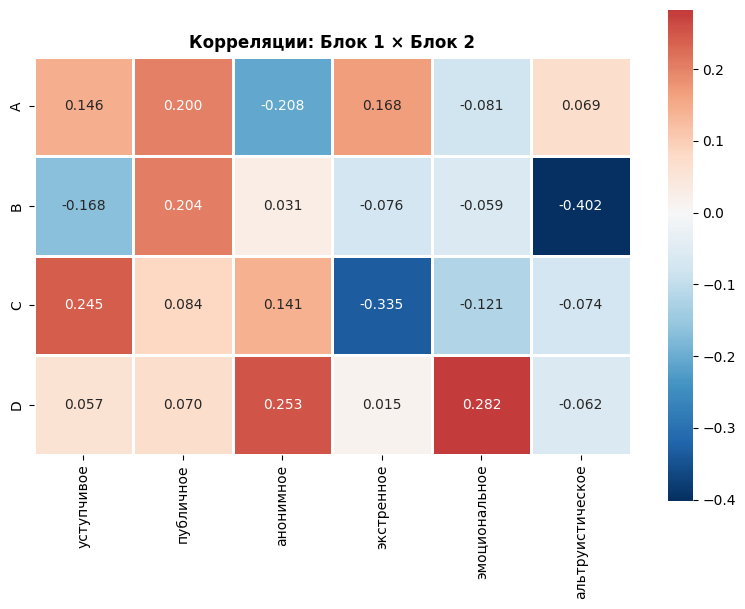

✅ Сохранено: correlation_between_block1_block2.png

Корреляции между A-D и компетенциями:
   Базовые коммуникативные умения  Межличностное понимание  \
A                           0.598                    0.037   
B                          -0.449                   -0.184   
C                          -0.334                   -0.337   
D                          -0.377                    0.132   

   Позитивное влияние  Ассертивные умения  Самоорганизация  Саморегуляция  \
A               0.297               0.140            0.358          0.119   
B              -0.338              -0.416           -0.260         -0.100   
C              -0.445              -0.094           -0.171         -0.424   
D              -0.301              -0.254           -0.061         -0.118   

   Сотрудничество  Организаторские умения  Регуляция конфликтов  \
A           0.310                   0.078                 0.007   
B          -0.222                  -0.314                -0.203   
C          -

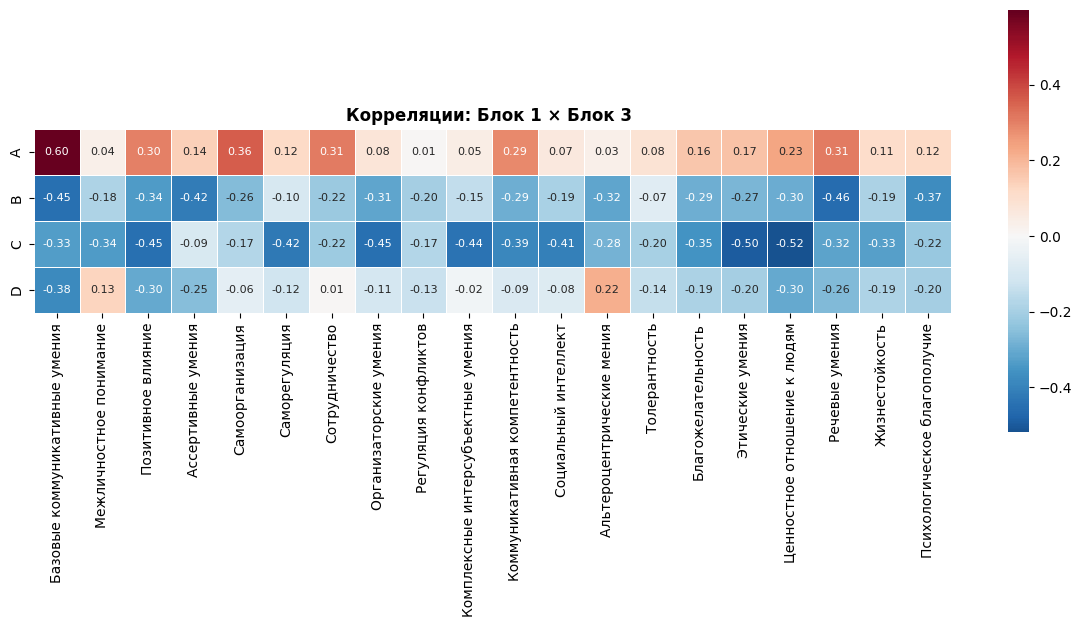


Корреляции между поведенческими стратегиями и компетенциями:
                  Базовые коммуникативные умения  Межличностное понимание  \
уступчивое                                 0.003                    0.282   
публичное                                 -0.124                    0.103   
анонимное                                 -0.135                    0.320   
экстренное                                 0.354                    0.562   
эмоциональное                             -0.068                    0.628   
альтруистическое                           0.333                    0.328   

                  Позитивное влияние  Ассертивные умения  Самоорганизация  \
уступчивое                     0.225               0.228            0.422   
публичное                     -0.161              -0.295            0.104   
анонимное                      0.105               0.168            0.146   
экстренное                     0.481               0.463            0.635   
эмоциональное

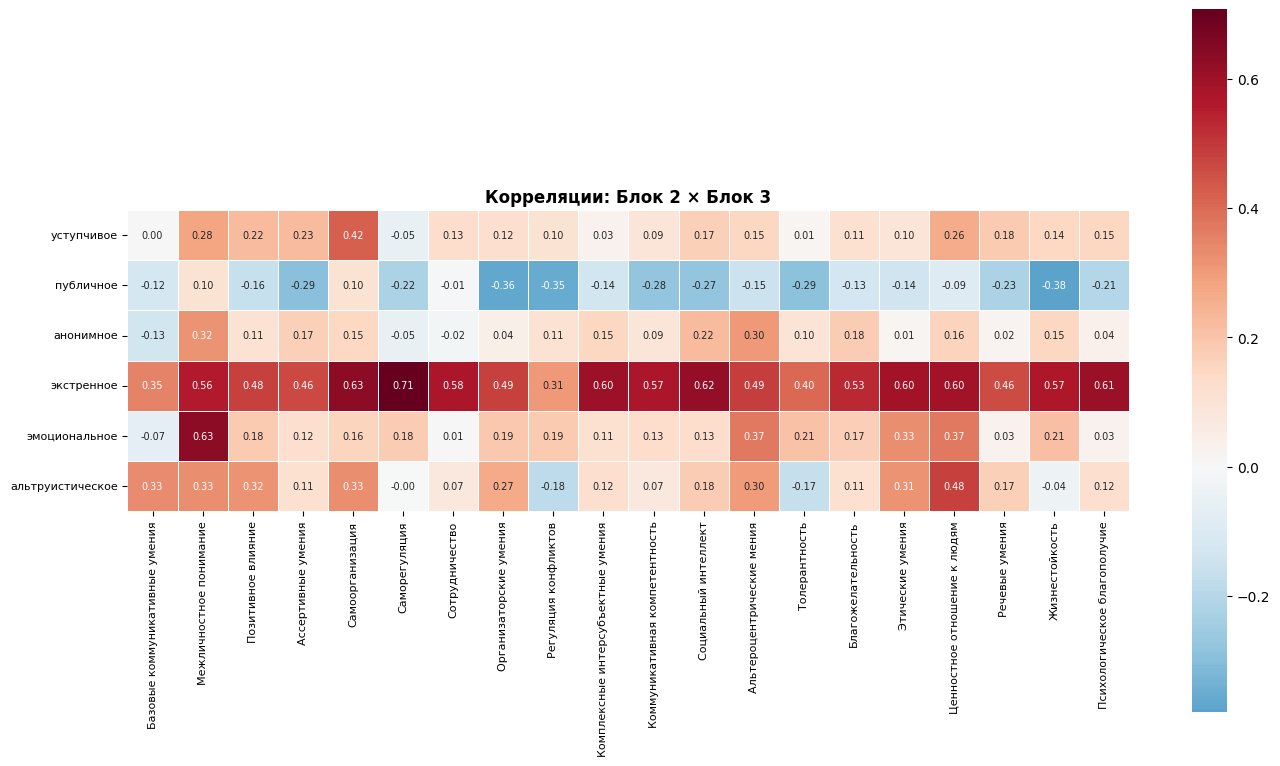

✅ Сохранено: correlation_between_block2_block3.png


In [ ]:
# ========== 5. КОРРЕЛЯЦИИ МЕЖДУ БЛОКАМИ ==========
print("\n" + "=" * 60)
print("КОРРЕЛЯЦИИ МЕЖДУ БЛОКАМИ")
print("=" * 60)

if len(block1_exists) > 0 and len(block2_exists) > 0:
    # Корреляции между блоком 1 и блоком 2
    corr_between_12 = df_numeric[block1_exists + block2_exists].corr()
    corr_12 = corr_between_12.loc[block1_exists, block2_exists]

    print("\nКорреляции между A-D и поведенческими стратегиями:")
    print(corr_12.round(3))

    # Тепловая карта связей между блоками 1 и 2
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_12,
                annot=True,
                fmt='.3f',
                cmap='RdBu_r',
                center=0,
                square=True,
                linewidths=1,
                annot_kws={'size': 10})
    plt.title('Корреляции: Блок 1 × Блок 2',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_between_block1_block2.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Сохранено: correlation_between_block1_block2.png")

if len(block1_exists) > 0 and len(block3_exists) > 0:
    # Корреляции между блоком 1 и блоком 3
    corr_between_13 = df_numeric[block1_exists + block3_exists].corr()
    corr_13 = corr_between_13.loc[block1_exists, block3_exists]

    print("\nКорреляции между A-D и компетенциями:")
    print(corr_13.round(3))

    plt.figure(figsize=(12, 6))
    sns.heatmap(corr_13,
                annot=True,
                fmt='.2f',
                cmap='RdBu_r',
                center=0,
                square=True,
                linewidths=0.5,
                annot_kws={'size': 8})
    plt.title('Корреляции: Блок 1 × Блок 3 ',
              fontsize=12, fontweight='bold')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.savefig('correlation_between_block1_block3.png', dpi=300, bbox_inches='tight')
    plt.show()


if len(block2_exists) > 0 and len(block3_exists) > 0:
    # Корреляции между блоком 2 и блоком 3
    corr_between_23 = df_numeric[block2_exists + block3_exists].corr()
    corr_23 = corr_between_23.loc[block2_exists, block3_exists]

    print("\nКорреляции между поведенческими стратегиями и компетенциями:")
    print(corr_23.round(3))

    plt.figure(figsize=(14, 8))
    sns.heatmap(corr_23,
                annot=True,
                fmt='.2f',
                cmap='RdBu_r',
                center=0,
                square=True,
                linewidths=0.5,
                annot_kws={'size': 7})
    plt.title('Корреляции: Блок 2 × Блок 3',
              fontsize=12, fontweight='bold')
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig('correlation_between_block2_block3.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Сохранено: correlation_between_block2_block3.png")

In [ ]:
# Сохранение корреляций между блоками в CSV
if len(block1_exists) > 0 and len(block2_exists) > 0:
    corr_12.to_csv('correlation_block1_vs_block2.csv', sep=';', encoding='utf-8')
    print("✅ Сохранено: correlation_block1_vs_block2.csv")

if len(block1_exists) > 0 and len(block3_exists) > 0:
    corr_13.to_csv('correlation_block1_vs_block3.csv', sep=';', encoding='utf-8')
    print("✅ Сохранено: correlation_block1_vs_block3.csv")

if len(block2_exists) > 0 and len(block3_exists) > 0:
    corr_23.to_csv('correlation_block2_vs_block3.csv', sep=';', encoding='utf-8')
    print("✅ Сохранено: correlation_block2_vs_block3.csv")

✅ Сохранено: correlation_block1_vs_block2.csv
✅ Сохранено: correlation_block1_vs_block3.csv
✅ Сохранено: correlation_block2_vs_block3.csv


In [ ]:
# Анализ сильных корреляций между блоками
print("\n" + "=" * 60)
print("АНАЛИЗ СИЛЬНЫХ КОРРЕЛЯЦИЙ МЕЖДУ БЛОКАМИ")
print("=" * 60)

# Собираем все межблоковые корреляции
between_block_correlations = []

if len(block1_exists) > 0 and len(block2_exists) > 0:
    for col1 in block1_exists:
        for col2 in block2_exists:
            corr_val = corr_12.loc[col1, col2]
            if abs(corr_val) >= 0.3:  # Порог для сильных корреляций
                between_block_correlations.append({
                    'Переменная_1': col1,
                    'Блок_1': 'A-D',
                    'Переменная_2': col2,
                    'Блок_2': 'Поведенческие стратегии',
                    'Корреляция': round(corr_val, 3)
                })

if len(block1_exists) > 0 and len(block3_exists) > 0:
    for col1 in block1_exists:
        for col2 in block3_exists:
            corr_val = corr_13.loc[col1, col2]
            if abs(corr_val) >= 0.3:
                between_block_correlations.append({
                    'Переменная_1': col1,
                    'Блок_1': 'A-D',
                    'Переменная_2': col2,
                    'Блок_2': 'Компетенции',
                    'Корреляция': round(corr_val, 3)
                })

if len(block2_exists) > 0 and len(block3_exists) > 0:
    for col1 in block2_exists:
        for col2 in block3_exists:
            corr_val = corr_23.loc[col1, col2]
            if abs(corr_val) >= 0.3:
                between_block_correlations.append({
                    'Переменная_1': col1,
                    'Блок_1': 'Поведенческие стратегии',
                    'Переменная_2': col2,
                    'Блок_2': 'Компетенции',
                    'Корреляция': round(corr_val, 3)
                })

# Создаем DataFrame с сильными межблоковыми корреляциями
if between_block_correlations:
    df_between_strong = pd.DataFrame(between_block_correlations)
    df_between_strong = df_between_strong.sort_values('Корреляция', key=abs, ascending=False)

    print(f"\nНайдено {len(df_between_strong)} сильных корреляций между блоками (|r| >= 0.3):")
    print(df_between_strong.to_string(index=False))

    # Сохраняем в CSV
    df_between_strong.to_csv('strong_between_block_correlations.csv', sep=';', encoding='utf-8', index=False)
    print("✅ Сохранено: strong_between_block_correlations.csv")
else:
    print("\nСильных корреляций между блоками не найдено.")


АНАЛИЗ СИЛЬНЫХ КОРРЕЛЯЦИЙ МЕЖДУ БЛОКАМИ

Найдено 66 сильных корреляций между блоками (|r| >= 0.3):
    Переменная_1                  Блок_1                       Переменная_2                  Блок_2  Корреляция
      экстренное Поведенческие стратегии                      Саморегуляция             Компетенции       0.707
      экстренное Поведенческие стратегии                    Самоорганизация             Компетенции       0.635
   эмоциональное Поведенческие стратегии            Межличностное понимание             Компетенции       0.628
      экстренное Поведенческие стратегии               Социальный интеллект             Компетенции       0.619
      экстренное Поведенческие стратегии       Психологическое благополучие             Компетенции       0.606
      экстренное Поведенческие стратегии Комплексные интерсубъектные умения             Компетенции       0.604
               A                     A-D     Базовые коммуникативные умения             Компетенции       0.598
    

In [ ]:
# Топ-20 корреляций между блоками
if between_block_correlations:
    df_between_strong_top20 = df_between_strong.head(20).copy()
    df_between_strong_top20['Абсолютная_корреляция'] = df_between_strong_top20['Корреляция'].abs()
    df_between_strong_top20 = df_between_strong_top20.sort_values('Абсолютная_корреляция', ascending=False)

    print("\nТоп-20 сильных корреляций между блоками:")
    print(df_between_strong_top20[['Переменная_1', 'Блок_1', 'Переменная_2', 'Блок_2', 'Корреляция']].to_string(index=False))

    # Сохраняем топ-20
    df_between_strong_top20.to_csv('top20_between_block_correlations.csv', sep=';', encoding='utf-8', index=False)
    print("✅ Сохранено: top20_between_block_correlations.csv")


Топ-20 сильных корреляций между блоками:
    Переменная_1                  Блок_1                       Переменная_2      Блок_2  Корреляция
      экстренное Поведенческие стратегии                      Саморегуляция Компетенции       0.707
      экстренное Поведенческие стратегии                    Самоорганизация Компетенции       0.635
   эмоциональное Поведенческие стратегии            Межличностное понимание Компетенции       0.628
      экстренное Поведенческие стратегии               Социальный интеллект Компетенции       0.619
      экстренное Поведенческие стратегии       Психологическое благополучие Компетенции       0.606
      экстренное Поведенческие стратегии Комплексные интерсубъектные умения Компетенции       0.604
               A                     A-D     Базовые коммуникативные умения Компетенции       0.598
      экстренное Поведенческие стратегии       Ценностное отношение к людям Компетенции       0.596
      экстренное Поведенческие стратегии                  

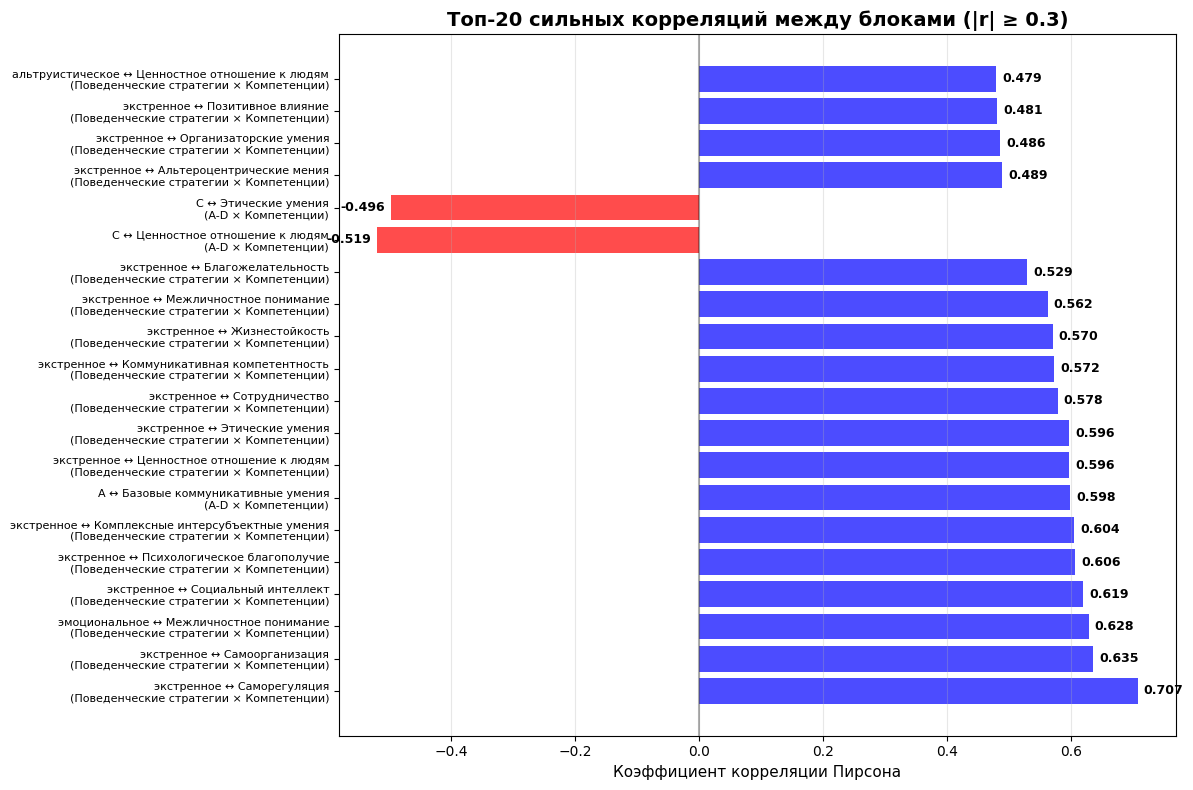

✅ Сохранено: top20_between_block_correlations.png


In [ ]:
# Визуализация топ-20 корреляций между блоками
if between_block_correlations:
    plt.figure(figsize=(12, 8))
    colors = ['red' if x < 0 else 'blue' for x in df_between_strong_top20['Корреляция']]
    bars = plt.barh(range(len(df_between_strong_top20)), df_between_strong_top20['Корреляция'],
                    color=colors, alpha=0.7)

    # Добавляем подписи
    for i, (idx, row) in enumerate(df_between_strong_top20.iterrows()):
        plt.text(row['Корреляция'] + (0.01 if row['Корреляция'] > 0 else -0.01),
                i, f"{row['Корреляция']:.3f}",
                va='center', ha='left' if row['Корреляция'] > 0 else 'right',
                fontsize=9, fontweight='bold')

    # Настраиваем оси
    plt.yticks(range(len(df_between_strong_top20)),
               [f"{row['Переменная_1']} ↔ {row['Переменная_2']}\n({row['Блок_1']} × {row['Блок_2']})"
                for _, row in df_between_strong_top20.iterrows()],
               fontsize=8)
    plt.xlabel('Коэффициент корреляции Пирсона', fontsize=11)
    plt.title('Топ-20 сильных корреляций между блоками (|r| ≥ 0.3)',
              fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('top20_between_block_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Сохранено: top20_between_block_correlations.png")

In [ ]:
# Итоговый анализ всех корреляций между блоками
print("\n" + "=" * 60)
print("ИТОГОВЫЙ АНАЛИЗ ВСЕХ КОРРЕЛЯЦИЙ МЕЖДУ БЛОКАМИ")
print("=" * 60)

# Собираем все межблоковые корреляции (не только сильные)
all_between_block_correlations = []

if len(block1_exists) > 0 and len(block2_exists) > 0:
    for col1 in block1_exists:
        for col2 in block2_exists:
            corr_val = corr_12.loc[col1, col2]
            all_between_block_correlations.append({
                'Переменная_1': col1,
                'Блок_1': 'A-D',
                'Переменная_2': col2,
                'Блок_2': 'Поведенческие стратегии',
                'Корреляция': round(corr_val, 3)
            })

if len(block1_exists) > 0 and len(block3_exists) > 0:
    for col1 in block1_exists:
        for col2 in block3_exists:
            corr_val = corr_13.loc[col1, col2]
            all_between_block_correlations.append({
                'Переменная_1': col1,
                'Блок_1': 'A-D',
                'Переменная_2': col2,
                'Блок_2': 'Компетенции',
                'Корреляция': round(corr_val, 3)
            })

if len(block2_exists) > 0 and len(block3_exists) > 0:
    for col1 in block2_exists:
        for col2 in block3_exists:
            corr_val = corr_23.loc[col1, col2]
            all_between_block_correlations.append({
                'Переменная_1': col1,
                'Блок_1': 'Поведенческие стратегии',
                'Переменная_2': col2,
                'Блок_2': 'Компетенции',
                'Корреляция': round(corr_val, 3)
            })

# Создаем DataFrame со всеми межблоковыми корреляциями
if all_between_block_correlations:
    df_all_between = pd.DataFrame(all_between_block_correlations)
    df_all_between = df_all_between.sort_values('Корреляция', key=abs, ascending=False)

    print(f"\nВсего корреляций между блоками: {len(df_all_between)}")
    print(f"Из них положительных: {len(df_all_between[df_all_between['Корреляция'] > 0])}")
    print(f"Из них отрицательных: {len(df_all_between[df_all_between['Корреляция'] < 0])}")

    # Сохраняем все корреляции между блоками
    df_all_between.to_csv('between_block_correlations_with_Психологическое благополучие.csv', sep=';', encoding='utf-8', index=False)
    print("✅ Сохранено: between_block_correlations_with_Психологическое благополучие.csv")

    # Статистика по блокам
    print("\nСтатистика корреляций по парам блоков:")
    block_pairs = df_all_between.groupby(['Блок_1', 'Блок_2']).agg({
        'Корреляция': ['count', 'mean', 'std', lambda x: (abs(x) >= 0.3).sum()]
    }).round(3)
    block_pairs.columns = ['Количество', 'Средняя', 'Стд_отклонение', 'Сильных_корреляций']
    print(block_pairs)


ИТОГОВЫЙ АНАЛИЗ ВСЕХ КОРРЕЛЯЦИЙ МЕЖДУ БЛОКАМИ

Всего корреляций между блоками: 224
Из них положительных: 130
Из них отрицательных: 94
✅ Сохранено: between_block_correlations_with_Психологическое благополучие.csv

Статистика корреляций по парам блоков:
                                                 Количество  Средняя  \
Блок_1                  Блок_2                                         
A-D                     Компетенции                      80   -0.139   
                        Поведенческие стратегии          24    0.016   
Поведенческие стратегии Компетенции                     120    0.157   

                                                 Стд_отклонение  \
Блок_1                  Блок_2                                    
A-D                     Компетенции                       0.235   
                        Поведенческие стратегии           0.181   
Поведенческие стратегии Компетенции                       0.246   

                                                 С

In [ ]:
# Финальное резюме анализа
import os

print("\n" + "=" * 80)
print("ФИНАЛЬНОЕ РЕЗЮМЕ АНАЛИЗА КОРРЕЛЯЦИЙ")
print("=" * 80)

print("\n📊 АНАЛИЗ ЗАВЕРШЕН!")
print("\n📁 СОХРАНЕННЫЕ ФАЙЛЫ:")

# Список всех созданных файлов
created_files = [
    'correlation_matrix_block1_A_D.csv',
    'correlation_matrix_block2_behavioral.csv',
    'correlation_matrix_block3_competencies.csv',
    'strong_correlations_all.csv',
    'summary_block_correlations.csv',
    'correlation_block1_vs_block2.csv',
    'correlation_block1_vs_block3.csv',
    'correlation_block2_vs_block3.csv',
    'strong_between_block_correlations.csv',
    'top20_between_block_correlations.csv',
    'between_block_correlations_with_Психологическое благополучие.csv'
]

for file in created_files:
    if os.path.exists(file):
        print(f"  ✅ {file}")
    else:
        print(f"  ❌ {file} (не найден)")

print("\n🖼️  СОХРАНЕННЫЕ ВИЗУАЛИЗАЦИИ:")
visualizations = [
    'correlation_matrix_block1.png',
    'correlation_matrix_block2.png',
    'correlation_matrix_block3.png',
    'strong_correlations_heatmap.png',
    'correlation_between_block1_block2.png',
    'correlation_between_block1_block3.png',
    'correlation_between_block2_block3.png',
    'top20_between_block_correlations.png'
]

for viz in visualizations:
    if os.path.exists(viz):
        print(f"  ✅ {viz}")
    else:
        print(f"  ❌ {viz} (не найден)")

print("\n🎯 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:")

# Выводим ключевые метрики
if 'df_all_between' in locals() and len(df_all_between) > 0:
    strong_corr = len(df_all_between[abs(df_all_between['Корреляция']) >= 0.3])
    print(f"  • Всего проанализировано корреляций между блоками: {len(df_all_between)}")
    print(f"  • Сильных корреляций (|r| ≥ 0.3): {strong_corr}")
    print(f"  • Максимальная корреляция: {df_all_between['Корреляция'].max():.3f}")
    print(f"  • Минимальная корреляция: {df_all_between['Корреляция'].min():.3f}")

print("\n📝 РЕКОМЕНДАЦИИ:")
print("  • Изучите сильные корреляции для понимания связей между переменными")
print("  • Обратите внимание на корреляции с психологическим благополучием")
print("  • Рассмотрите возможность дальнейшего статистического анализа")

print("\n" + "=" * 80)
print("АНАЛИЗ ЗАВЕРШЕН УСПЕШНО! 🎉")
print("=" * 80)


ФИНАЛЬНОЕ РЕЗЮМЕ АНАЛИЗА КОРРЕЛЯЦИЙ

📊 АНАЛИЗ ЗАВЕРШЕН!

📁 СОХРАНЕННЫЕ ФАЙЛЫ:
  ✅ correlation_matrix_block1_A_D.csv
  ✅ correlation_matrix_block2_behavioral.csv
  ✅ correlation_matrix_block3_competencies.csv
  ❌ strong_correlations_all.csv (не найден)
  ❌ summary_block_correlations.csv (не найден)
  ✅ correlation_block1_vs_block2.csv
  ✅ correlation_block1_vs_block3.csv
  ✅ correlation_block2_vs_block3.csv
  ✅ strong_between_block_correlations.csv
  ✅ top20_between_block_correlations.csv
  ✅ between_block_correlations_with_Психологическое благополучие.csv

🖼️  СОХРАНЕННЫЕ ВИЗУАЛИЗАЦИИ:
  ❌ correlation_matrix_block1.png (не найден)
  ❌ correlation_matrix_block2.png (не найден)
  ❌ correlation_matrix_block3.png (не найден)
  ❌ strong_correlations_heatmap.png (не найден)
  ✅ correlation_between_block1_block2.png
  ✅ correlation_between_block1_block3.png
  ✅ correlation_between_block2_block3.png
  ✅ top20_between_block_correlations.png

🎯 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:
  • Всего проанализировано ко

## 4. Корреляции с благополучием

In [ ]:
# ========== 8. КОРРЕЛЯЦИИ С ПСИХОЛОГИЧЕСКИМ БЛАГОПОЛУЧИЕМ ==========
target = 'Психологическое благополучие'
if target in corr_matrix.columns:
    print("\n" + "=" * 80)
    print(f"КОРРЕЛЯЦИИ С ПЕРЕМЕННОЙ: {target} (только межблоковые)")
    print("=" * 80)

    target_corr = corr_matrix[target].sort_values(ascending=False)

    print("\nПеременные из других блоков, коррелирующие с психологическим благополучием:\n")
    for var, r in target_corr.items():
        if var != target:
            var_block = get_block(var)
            if var_block != 'Блок 3 (компетенции и благополучие)':  # Только из других блоков
                if abs(r) >= 0.7:
                    icon = "🔴"
                    level = "ОЧЕНЬ СИЛЬНАЯ"
                elif abs(r) >= 0.5:
                    icon = "🟠"
                    level = "СИЛЬНАЯ"
                elif abs(r) >= 0.3:
                    icon = "🟡"
                    level = "УМЕРЕННАЯ"
                else:
                    icon = "⚪"
                    level = "СЛАБАЯ"

                print(f"{icon} {var} [{var_block}]: r = {r:.3f} ({level})")

    # Сохраняем только межблоковые корреляции с целевой переменной
    target_between = []
    for var, r in target_corr.items():
        if var != target and get_block(var) != 'Блок 3 (компетенции и благополучие)':
            target_between.append({
                'Переменная': var,
                'Блок': get_block(var),
                'Корреляция с Психологическим благополучием': round(r, 3)
            })

    if target_between:
        target_between_df = pd.DataFrame(target_between)
        target_between_df.to_csv(f"between_block_correlations_with_{target}.csv", index=False, encoding='utf-8-sig')



КОРРЕЛЯЦИИ С ПЕРЕМЕННОЙ: Психологическое благополучие (только межблоковые)

Переменные из других блоков, коррелирующие с психологическим благополучием:

🟠 экстренное [Блок 2 (поведенческие стратегии)]: r = 0.606 (СИЛЬНАЯ)
⚪ уступчивое [Блок 2 (поведенческие стратегии)]: r = 0.152 (СЛАБАЯ)
⚪ A [Блок 1 (A-D)]: r = 0.120 (СЛАБАЯ)
⚪ альтруистическое [Блок 2 (поведенческие стратегии)]: r = 0.118 (СЛАБАЯ)
⚪ анонимное [Блок 2 (поведенческие стратегии)]: r = 0.037 (СЛАБАЯ)
⚪ эмоциональное [Блок 2 (поведенческие стратегии)]: r = 0.032 (СЛАБАЯ)
⚪ D [Блок 1 (A-D)]: r = -0.202 (СЛАБАЯ)
⚪ публичное [Блок 2 (поведенческие стратегии)]: r = -0.206 (СЛАБАЯ)
⚪ C [Блок 1 (A-D)]: r = -0.222 (СЛАБАЯ)
🟡 B [Блок 1 (A-D)]: r = -0.373 (УМЕРЕННАЯ)


## 5. Средние корреляции между блоками

In [ ]:
# ========== 9. СРЕДНИЕ КОРРЕЛЯЦИИ МЕЖДУ БЛОКАМИ ==========
print("\n" + "=" * 80)
print("СРЕДНИЕ КОРРЕЛЯЦИИ МЕЖДУ БЛОКАМИ ПЕРЕМЕННЫХ")
print("=" * 80)

def calculate_block_correlations(block1, block2, df, block1_name, block2_name):
    """Расчёт средних корреляций между двумя блоками переменных"""
    if len(block1) > 0 and len(block2) > 0:
        # Матрица корреляций между блоками
        corr_between = df[block1 + block2].corr().loc[block1, block2]

        # Основные статистики
        mean_corr = corr_between.mean().mean()
        median_corr = corr_between.median().median()
        std_corr = corr_between.stack().std()
        max_corr = corr_between.max().max()
        min_corr = corr_between.min().min()
        positive_pct = (corr_between > 0).sum().sum() / corr_between.size * 100
        negative_pct = (corr_between < 0).sum().sum() / corr_between.size * 100

        # Находим максимальную и минимальную корреляции
        max_pair = corr_between.stack().idxmax()
        min_pair = corr_between.stack().idxmin()

        return {
            'mean': mean_corr,
            'median': median_corr,
            'std': std_corr,
            'max': max_corr,
            'max_pair': f"{max_pair[0]} ↔ {max_pair[1]}",
            'min': min_corr,
            'min_pair': f"{min_pair[0]} ↔ {min_pair[1]}",
            'positive_pct': positive_pct,
            'negative_pct': negative_pct,
            'corr_matrix': corr_between
        }
    return None

# 9.1 Блок 1 vs Блок 2
print("\n📊 БЛОК 1 (A-D) vs БЛОК 2 (поведенческие стратегии):")
print("-" * 60)
stats_12 = calculate_block_correlations(block1_exists, block2_exists, df_numeric, "Блок1", "Блок2")
if stats_12:
    print(f"   Средняя корреляция: {stats_12['mean']:.3f}")
    print(f"   Медиана: {stats_12['median']:.3f}")
    print(f"   Стандартное отклонение: {stats_12['std']:.3f}")
    print(f"   Диапазон: от {stats_12['min']:.3f} до {stats_12['max']:.3f}")
    print(f"   Максимальная связь: {stats_12['max_pair']} (r = {stats_12['max']:.3f})")
    print(f"   Минимальная связь: {stats_12['min_pair']} (r = {stats_12['min']:.3f})")
    print(f"   Положительные корреляции: {stats_12['positive_pct']:.1f}%")
    print(f"   Отрицательные корреляции: {stats_12['negative_pct']:.1f}%")

    stats_12['corr_matrix'].to_csv("correlation_block1_vs_block2.csv", encoding='utf-8-sig')

# 9.2 Блок 1 vs Блок 3
print("\n📊 БЛОК 1 (A-D) vs БЛОК 3 (компетенции и благополучие):")
print("-" * 60)
stats_13 = calculate_block_correlations(block1_exists, block3_exists, df_numeric, "Блок1", "Блок3")
if stats_13:
    print(f"   Средняя корреляция: {stats_13['mean']:.3f}")
    print(f"   Медиана: {stats_13['median']:.3f}")
    print(f"   Стандартное отклонение: {stats_13['std']:.3f}")
    print(f"   Диапазон: от {stats_13['min']:.3f} до {stats_13['max']:.3f}")
    print(f"   Максимальная связь: {stats_13['max_pair']} (r = {stats_13['max']:.3f})")
    print(f"   Минимальная связь: {stats_13['min_pair']} (r = {stats_13['min']:.3f})")
    print(f"   Положительные корреляции: {stats_13['positive_pct']:.1f}%")
    print(f"   Отрицательные корреляции: {stats_13['negative_pct']:.1f}%")

    stats_13['corr_matrix'].to_csv("correlation_block1_vs_block3.csv", encoding='utf-8-sig')

# 9.3 Блок 2 vs Блок 3
print("\n📊 БЛОК 2 (поведенческие стратегии) vs БЛОК 3 (компетенции и благополучие):")
print("-" * 60)
stats_23 = calculate_block_correlations(block2_exists, block3_exists, df_numeric, "Блок2", "Блок3")
if stats_23:
    print(f"   Средняя корреляция: {stats_23['mean']:.3f}")
    print(f"   Медиана: {stats_23['median']:.3f}")
    print(f"   Стандартное отклонение: {stats_23['std']:.3f}")
    print(f"   Диапазон: от {stats_23['min']:.3f} до {stats_23['max']:.3f}")
    print(f"   Максимальная связь: {stats_23['max_pair']} (r = {stats_23['max']:.3f})")
    print(f"   Минимальная связь: {stats_23['min_pair']} (r = {stats_23['min']:.3f})")
    print(f"   Положительные корреляции: {stats_23['positive_pct']:.1f}%")
    print(f"   Отрицательные корреляции: {stats_23['negative_pct']:.1f}%")

    stats_23['corr_matrix'].to_csv("correlation_block2_vs_block3.csv", encoding='utf-8-sig')


СРЕДНИЕ КОРРЕЛЯЦИИ МЕЖДУ БЛОКАМИ ПЕРЕМЕННЫХ

📊 БЛОК 1 (A-D) vs БЛОК 2 (поведенческие стратегии):
------------------------------------------------------------
   Средняя корреляция: 0.016
   Медиана: 0.028
   Стандартное отклонение: 0.181
   Диапазон: от -0.402 до 0.282
   Максимальная связь: D ↔ эмоциональное (r = 0.282)
   Минимальная связь: B ↔ альтруистическое (r = -0.402)
   Положительные корреляции: 58.3%
   Отрицательные корреляции: 41.7%

📊 БЛОК 1 (A-D) vs БЛОК 3 (компетенции и благополучие):
------------------------------------------------------------
   Средняя корреляция: -0.139
   Медиана: -0.181
   Стандартное отклонение: 0.235
   Диапазон: от -0.519 до 0.598
   Максимальная связь: A ↔ Базовые коммуникативные умения (r = 0.598)
   Минимальная связь: C ↔ Ценностное отношение к людям (r = -0.519)
   Положительные корреляции: 28.7%
   Отрицательные корреляции: 71.2%

📊 БЛОК 2 (поведенческие стратегии) vs БЛОК 3 (компетенции и благополучие):
-----------------------------------

## 6. Визуализация

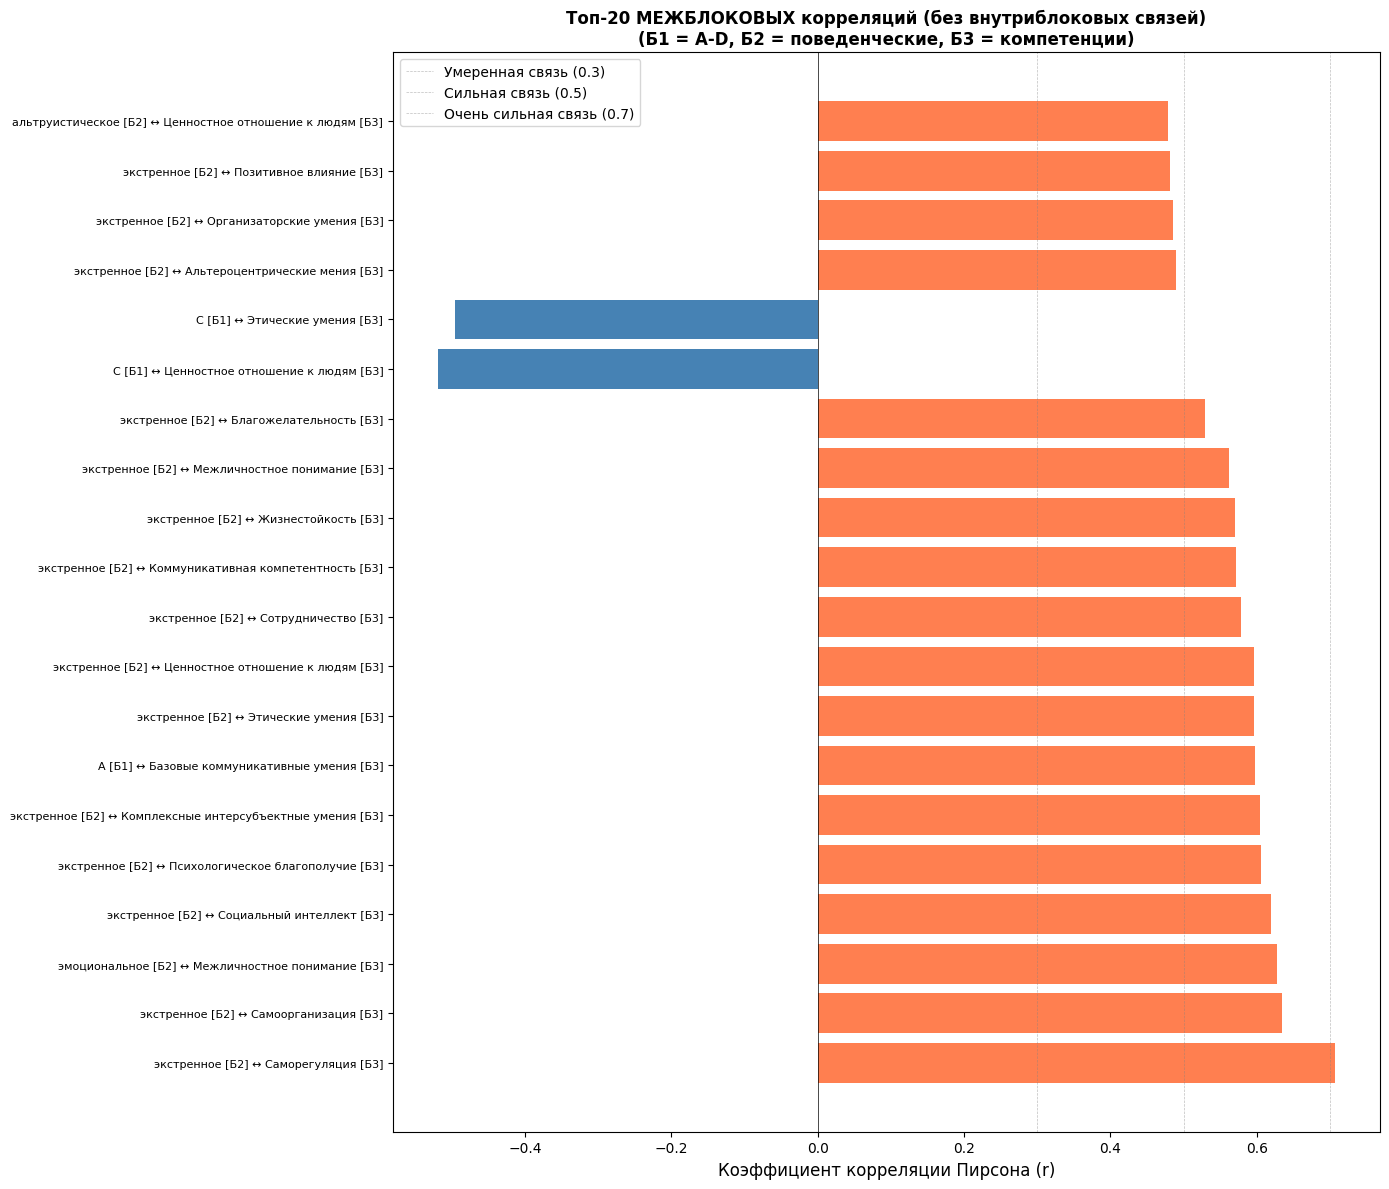

In [ ]:
# ========== 10.1 БАРПЛОТ ТОП-20 МЕЖБЛОКОВЫХ КОРРЕЛЯЦИЙ ==========
all_between = [c for c in all_correlations if c['Тип связи'] == 'Межблоковая']
all_between.sort(key=lambda x: abs(x['r (Пирсона)']), reverse=True)
top20_between = all_between[:20]
# 10.1 Барплот топ-20 межблоковых корреляций
if top20_between:
    plt.figure(figsize=(14, 12))

    # Создаём подписи с блоками (сокращённые)
    labels = []
    colors = []
    for corr in top20_between:
        label = f"{corr['Переменная 1']} [{get_block_short(corr['Переменная 1'])}] ↔ {corr['Переменная 2']} [{get_block_short(corr['Переменная 2'])}]"
        labels.append(label)
        if corr['r (Пирсона)'] > 0:
            colors.append('coral')
        else:
            colors.append('steelblue')

    bars = plt.barh(range(len(top20_between)), [c['r (Пирсона)'] for c in top20_between], color=colors)

    plt.yticks(range(len(top20_between)), labels, fontsize=8)
    plt.xlabel('Коэффициент корреляции Пирсона (r)', fontsize=12)
    plt.title('Топ-20 МЕЖБЛОКОВЫХ корреляций (без внутриблоковых связей)\n(Б1 = A-D, Б2 = поведенческие, Б3 = компетенции)',
              fontsize=12, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.axvline(x=0.3, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='Умеренная связь (0.3)')
    plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='Сильная связь (0.5)')
    plt.axvline(x=0.7, color='gray', linestyle='--', linewidth=0.5, alpha=0.5, label='Очень сильная связь (0.7)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('top20_between_block_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()

## 7. Итоговые результаты

In [ ]:
# ========== 11. ИТОГОВАЯ ТАБЛИЦА ==========
print("\n" + "=" * 80)
print("СВОДНАЯ ТАБЛИЦА СРЕДНИХ МЕЖБЛОКОВЫХ КОРРЕЛЯЦИЙ")
print("=" * 80)

summary_table = pd.DataFrame({
    'Пары блоков': [
        'Блок 1 ↔ Блок 2',
        'Блок 1 ↔ Блок 3',
        'Блок 2 ↔ Блок 3'
    ],
    'Средняя r': [
        stats_12['mean'] if stats_12 else np.nan,
        stats_13['mean'] if stats_13 else np.nan,
        stats_23['mean'] if stats_23 else np.nan
    ],
    'Медиана': [
        stats_12['median'] if stats_12 else np.nan,
        stats_13['median'] if stats_13 else np.nan,
        stats_23['median'] if stats_23 else np.nan
    ],
    'Станд. отклонение': [
        stats_12['std'] if stats_12 else np.nan,
        stats_13['std'] if stats_13 else np.nan,
        stats_23['std'] if stats_23 else np.nan
    ],
    'Максимум': [
        stats_12['max'] if stats_12 else np.nan,
        stats_13['max'] if stats_13 else np.nan,
        stats_23['max'] if stats_23 else np.nan
    ],
    'Минимум': [
        stats_12['min'] if stats_12 else np.nan,
        stats_13['min'] if stats_13 else np.nan,
        stats_23['min'] if stats_23 else np.nan
    ]
})

print(summary_table.round(3).to_string(index=False))
summary_table.to_csv("summary_between_block_correlations.csv", index=False, encoding='utf-8-sig')
print("\n✅ Сохранено: summary_between_block_correlations.csv")


СВОДНАЯ ТАБЛИЦА СРЕДНИХ МЕЖБЛОКОВЫХ КОРРЕЛЯЦИЙ
    Пары блоков  Средняя r  Медиана  Станд. отклонение  Максимум  Минимум
Блок 1 ↔ Блок 2      0.016    0.028              0.181     0.282   -0.402
Блок 1 ↔ Блок 3     -0.139   -0.181              0.235     0.598   -0.519
Блок 2 ↔ Блок 3      0.157    0.144              0.246     0.707   -0.379

✅ Сохранено: summary_between_block_correlations.csv


## 8. Выводы

In [ ]:
# ========== 12. ВЫВОДЫ ==========
print("\n" + "=" * 80)
print("ОСНОВНЫЕ ВЫВОДЫ (только межблоковые связи)")
print("=" * 80)

if strong_between:
    print(f"✅ Обнаружено {len(strong_between)} сильных межблоковых корреляций (|r| ≥ 0.5)")

    very_strong_between = [c for c in strong_between if abs(c['r (Пирсона)']) >= 0.7]
    if very_strong_between:
        print(f"✅ Из них {len(very_strong_between)} очень сильных (|r| ≥ 0.7)")
        print("   Наиболее сильные межблоковые связи:")
        for vs in very_strong_between[:3]:
            print(f"   • {vs['Переменная 1']} [{get_block_short(vs['Переменная 1'])}] ↔ {vs['Переменная 2']} [{get_block_short(vs['Переменная 2'])}]: r = {vs['r (Пирсона)']:.3f}")

# Сравнение межблоковых связей
if stats_23 and stats_12 and stats_13:
    print(f"\n📊 Сравнение средних межблоковых корреляций:")
    print(f"   Блок 1 ↔ Блок 2: {stats_12['mean']:.3f}")
    print(f"   Блок 1 ↔ Блок 3: {stats_13['mean']:.3f}")
    print(f"   Блок 2 ↔ Блок 3: {stats_23['mean']:.3f}")

    # Находим最强的 связь
    max_mean = max(stats_12['mean'], stats_13['mean'], stats_23['mean'])
    if max_mean == stats_23['mean']:
        print(f"\n✅ Наибольшая связь наблюдается между Блоком 2 (поведенческие стратегии) и Блоком 3 (компетенции и благополучие)")
    elif max_mean == stats_13['mean']:
        print(f"\n✅ Наибольшая связь наблюдается между Блоком 1 (A-D) и Блоком 3 (компетенции и благополучие)")
    else:
        print(f"\n✅ Наибольшая связь наблюдается между Блоком 1 (A-D) и Блоком 2 (поведенческие стратегии)")

print("\n" + "=" * 80)
print("ВСЕ ФАЙЛЫ УСПЕШНО СОЗДАНЫ!")
print("=" * 80)
print("\n📁 Созданные файлы:")
print("   • strong_between_block_correlations.csv - сильные межблоковые корреляции")
print("   • top20_between_block_correlations.csv - топ-20 межблоковых корреляций")
print("   • between_block_correlations_with_Психологическое_благополучие.csv - межблоковые корреляции с благополучием")
print("   • summary_between_block_correlations.csv - сводная статистика")
print("   • top20_between_block_correlations.png - барплот топ-20 межблоковых корреляций")
print("   • interblock_correlations_only.png - тепловые карты межблоковых связей")


ОСНОВНЫЕ ВЫВОДЫ (только межблоковые связи)
✅ Обнаружено 15 сильных межблоковых корреляций (|r| ≥ 0.5)
✅ Из них 1 очень сильных (|r| ≥ 0.7)
   Наиболее сильные межблоковые связи:
   • экстренное [Б2] ↔ Саморегуляция [Б3]: r = 0.707

📊 Сравнение средних межблоковых корреляций:
   Блок 1 ↔ Блок 2: 0.016
   Блок 1 ↔ Блок 3: -0.139
   Блок 2 ↔ Блок 3: 0.157

✅ Наибольшая связь наблюдается между Блоком 2 (поведенческие стратегии) и Блоком 3 (компетенции и благополучие)

ВСЕ ФАЙЛЫ УСПЕШНО СОЗДАНЫ!

📁 Созданные файлы:
   • strong_between_block_correlations.csv - сильные межблоковые корреляции
   • top20_between_block_correlations.csv - топ-20 межблоковых корреляций
   • between_block_correlations_with_Психологическое_благополучие.csv - межблоковые корреляции с благополучием
   • summary_between_block_correlations.csv - сводная статистика
   • top20_between_block_correlations.png - барплот топ-20 межблоковых корреляций
   • interblock_correlations_only.png - тепловые карты межблоковых связей
